In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [2]:
dataset_path = "../dataset"

In [3]:
with_mask_path = os.path.join(dataset_path, "with_mask")
without_mask_path = os.path.join(dataset_path, "without_mask")

print("With Mask:", len(os.listdir(with_mask_path)))
print("Without Mask:", len(os.listdir(without_mask_path)))
print("Total:", len(os.listdir(with_mask_path)) + len(os.listdir(without_mask_path)))

With Mask: 3725
Without Mask: 3828
Total: 7553


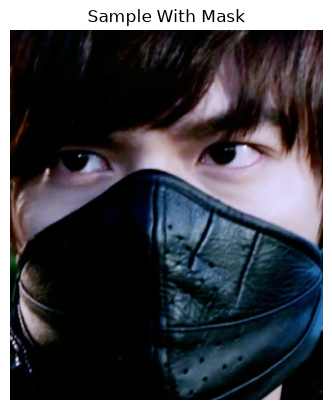

In [4]:
mask_img = cv2.imread(
    os.path.join(with_mask_path, os.listdir(with_mask_path)[100])
)

mask_img = cv2.cvtColor(mask_img, cv2.COLOR_BGR2RGB)

plt.imshow(mask_img)
plt.title("Sample With Mask")
plt.axis("off")
plt.show()

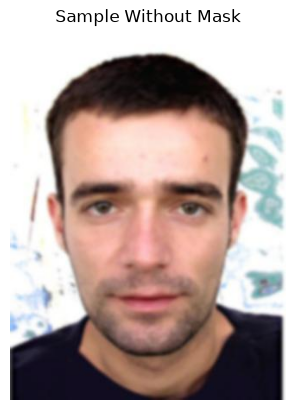

In [5]:
nomask_img = cv2.imread(
    os.path.join(without_mask_path, os.listdir(without_mask_path)[220])
)

nomask_img = cv2.cvtColor(nomask_img, cv2.COLOR_BGR2RGB)

plt.imshow(nomask_img)
plt.title("Sample Without Mask")
plt.axis("off")
plt.show()

In [6]:
categories = ["with_mask", "without_mask"]

data = []
labels = []

IMG_SIZE = 128

for category in categories:

    path = os.path.join(dataset_path, category)

    label = categories.index(category)

    for img in os.listdir(path):

        try:
            img_path = os.path.join(path, img)

            image = cv2.imread(img_path)

            image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))

            data.append(image)
            labels.append(label)

        except:
            pass

print("Total Images Loaded:", len(data))

Total Images Loaded: 7553


In [7]:
X = np.array(data)
y = np.array(labels)

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (7553, 128, 128, 3)
y Shape: (7553,)


In [8]:
X = X / 255.0

print("Normalization Completed")

Normalization Completed


In [9]:
from tensorflow.keras.utils import to_categorical

y = to_categorical(y)

print("Label Shape:", y.shape)

Label Shape: (7553, 2)


In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (6042, 128, 128, 3)
Testing Shape: (1511, 128, 128, 3)


In [11]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout

model = Sequential()

# Convolution Block 1
model.add(Conv2D(32, (3,3), activation='relu',
                 input_shape=(128,128,3)))
model.add(MaxPooling2D(pool_size=(2,2)))

# Convolution Block 2
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

# Convolution Block 3
model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

# Fully Connected Layer
model.add(Flatten())

model.add(Dense(128, activation='relu'))

model.add(Dropout(0.5))

model.add(Dense(2, activation='softmax'))

model.summary()

C:\Users\manvith hm\AppData\Local\Python\pythoncore-3.11-64\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 126, 126, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 61, 61, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 28, 28, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │       3,211,392 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 2)                   │             258 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,304,898 (12.61 MB)

 Trainable params: 3,304,898 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model Compiled Successfully")

Model Compiled Successfully


In [13]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=32
)

Epoch 1/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 27s 127ms/step - accuracy: 0.8292 - loss: 0.3888 - val_accuracy: 0.8537 - val_loss: 0.3243
Epoch 2/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 22s 119ms/step - accuracy: 0.8962 - loss: 0.2589 - val_accuracy: 0.8941 - val_loss: 0.2457
Epoch 3/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 22s 116ms/step - accuracy: 0.9050 - loss: 0.2331 - val_accuracy: 0.9120 - val_loss: 0.2066
Epoch 4/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 22s 116ms/step - accuracy: 0.9254 - loss: 0.1814 - val_accuracy: 0.9232 - val_loss: 0.2075
Epoch 5/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 22s 116ms/step - accuracy: 0.9379 - loss: 0.1652 - val_accuracy: 0.9424 - val_loss: 0.1662
Epoch 6/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 22s 116ms/step - accuracy: 0.9515 - loss: 0.1362 - val_accuracy: 0.9212 - val_loss: 0.2268
Epoch 7/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 22s 116ms/step - accuracy: 0.9535 - loss: 0.1278 - val_accuracy: 0.9398 - val_loss: 0.1741
Epoch 8/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 22s 114ms/step - accuracy: 0.9631 - loss: 0

In [14]:
model.save("../models/face_mask_model.h5")
print("Model Saved Successfully")

Model Saved Successfully


In [15]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.9570 - loss: 0.1441
Test Loss: 0.1441236138343811
Test Accuracy: 0.9569821357727051


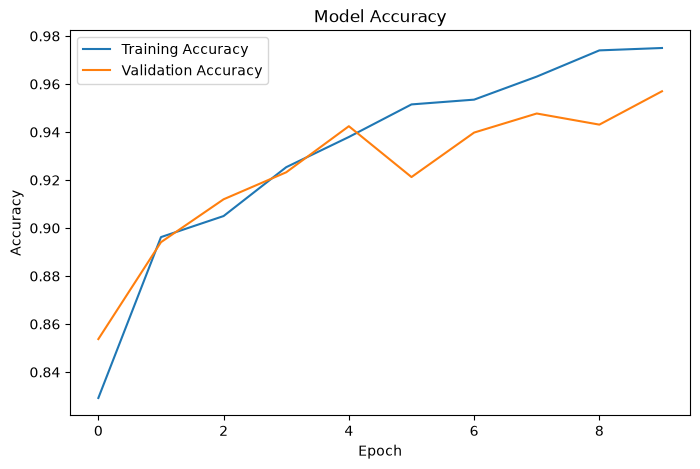

In [16]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.savefig("../images/accuracy_graph.png")
plt.show()

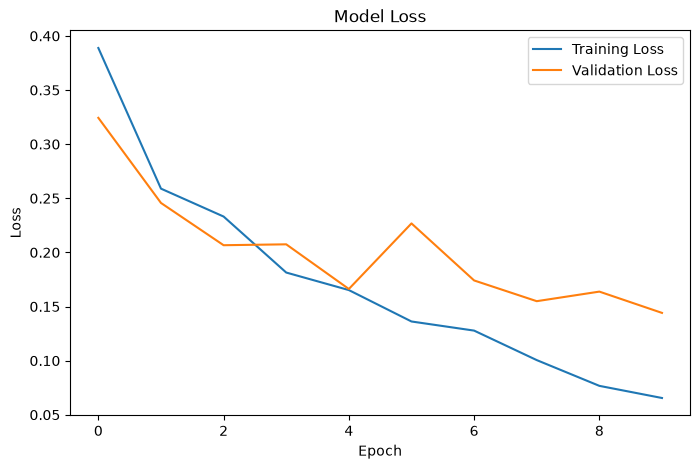

In [17]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.savefig("../images/loss_graph.png")
plt.show()

In [18]:
import cv2
face_cascade = cv2.CascadeClassifier(
    "../../haarcascade/haarcascade_frontalface_default.xml"
)
cap = cv2.VideoCapture(0)

while True:
    ret, frame = cap.read()

    if not ret:
        break
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(
        gray,
        scaleFactor=1.1,
        minNeighbors=5
    )

    for (x, y, w, h) in faces:

        cv2.rectangle(
            frame,
            (x, y),
            (x+w, y+h),
            (0, 255, 0),
            2
        )
    cv2.imshow("Face Detection Test", frame)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

In [3]:
import cv2
import numpy as np
import winsound
import time
from tensorflow.keras.models import load_model

model = load_model("../models/face_mask_model.h5")
face_cascade = cv2.CascadeClassifier(
    "../../haarcascade/haarcascade_frontalface_default.xml"
)
cap = cv2.VideoCapture(0)
last_beep = 0
warning_until = 0

while True:
    ret, frame = cap.read()
    if not ret:
        break
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(
        gray,
        scaleFactor=1.1,
        minNeighbors=5
    )

    for (x, y, w, h) in faces:
        face = frame[y:y+h, x:x+w]
        face = cv2.resize(face, (128, 128))
        face = face / 255.0
        face = np.expand_dims(face, axis=0)
        prediction = model.predict(face, verbose=0)
        label = np.argmax(prediction)

        if label == 0:
            text = "WITH MASK"
            color = (0, 255, 0)
            warning_until = 0

        else:
            text = "WITHOUT MASK"
            color = (0, 0, 255)
            warning_until = time.time() + 3
            
            current_time = time.time()
            if current_time - last_beep > 2:
                winsound.Beep(1000, 250)

                last_beep = current_time

        cv2.rectangle(
            frame,
            (x, y),
            (x + w, y + h),
            color,
            2
        )

        cv2.putText(
            frame,
            text,
            (x, y - 10),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.8,
            color,
            2
        )

    if time.time() < warning_until:

        cv2.putText(
            frame,
            "PLEASE WEAR THE MASK",
            (20, 50),
            cv2.FONT_HERSHEY_COMPLEX,
            1,
            (0, 0, 255),
            2
        )

    cv2.imshow("Face Mask Detection", frame)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()